In [3]:
from idlelib.iomenu import encoding

import pandas as pd
from openpyxl.chart import label

df=pd.read_csv('C:/Users/ASUS/Desktop/iris.csv',header=None,names=['sepal_length','sepal_width','petal_length','petal_width','class'])
print(df.head())
print(df.info())   #查看每列数据类型和非空数量
print(df.describe())      # 快速统计

   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333

In [4]:
import akshare as ak
df=ak.stock_zh_a_hist(symbol="600519",period="daily",start_date="20240501",end_date="20260506",adjust="qfq")
# qfq 下载前复权股价，消除分红除权影响。这个是向前调整当前价格，这样看到的价格曲线是连贯的，最常用。    hfg  后复权，保持历史价格不变，向后调整当前价格
df.to_csv('maotai.csv',index=False,encoding='utf-8-sig') #保存csv时添加BOM标记，使Excel能正确显示中文
print("数据已保存到 maotai.csv",len(df),"条记录")

数据已保存到 maotai.csv 485 条记录


In [5]:
import numpy as np
df=pd.read_csv('maotai.csv',encoding='utf-8-sig',parse_dates=['日期'])
# parse_dates=['日期']：将 CSV 中的“日期”列直接解析为 Pandas 的 datetime 类型（时间格式），方便后续时间序列操作。
df.set_index('日期',inplace=True)
# df.set_index('日期', inplace=True)：将“日期”列设为 DataFrame 的行索引。True则表示直接在原来的DataFrame上修改，不创建新的副本，False（默认值）则是创建新副本。这样将来画图时 x 轴会自动按时间排列，做时间窗口计算（如移动平均）也更方便。
df.head()

,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
日期,,,,,,,,,,,
2024-05-06,600519,1627.65,1653.88,1658.68,1620.68,59909,1.050435e+10,2.38,3.45,55.20,0.48
2024-05-07,600519,1659.47,1663.68,1671.48,1650.36,24925,4.413196e+09,1.28,0.59,9.80,0.20
2024-05-08,600519,1663.37,1657.65,1663.65,1649.35,14769,2.603294e+09,0.86,-0.36,-6.03,0.12
2024-05-09,600519,1651.68,1649.68,1658.66,1643.68,22387,3.929805e+09,0.90,-0.48,-7.97,0.18
2024-05-10,600519,1654.78,1632.66,1661.56,1627.67,26207,4.571398e+09,2.05,-1.03,-17.02,0.21


# D老师笔记
## 方式1：不修改原 df，返回新 df
df2 = df.set_index('日期', inplace=False)   # df 不变，df2 的索引是日期

## 方式2：直接修改原 df
df.set_index('日期', inplace=True)         # df 自己的索引变成了日期

inplace 是编程中常用的术语，意思是 “在原来的位置”（in-place），来源于原地算法（in-place algorithm）。
inplace=True → 在原对象上直接改，不额外占用内存创建新对象。
inplace=False → 先复制一份，在副本上改，然后返回副本。
很多 Python 库（如 Pandas）都遵循这个命名习惯，例如 df.dropna(inplace=True)、df.fillna(0, inplace=True) 等。

行索引：通过 set_index 或 index 属性设置。
列索引：通过 columns 属性设置，例如 df.columns = ['A','B','C']

In [6]:
# 计算简单日收益率（pct_change) 计算当前行与前一行相比的百分比变化。公式：(今日收盘 - 昨日收盘) / 昨日收盘。
df['ret']=df['收盘'].pct_change()
# 计算对数收益率
df['log_ret']=np.log(df['收盘']/df['收盘'].shift(1))
# 查看前几行，检查有无NaN（第一行无法计算收益率） 结果保存在新列 ret 中。第一行没有前一天数据，所以是 NaN
df[['收盘','ret','log_ret']].head(10)

,收盘,ret,log_ret
日期,,,
2024-05-06,1653.88,NaN,NaN
2024-05-07,1663.68,0.005925,0.005908
2024-05-08,1657.65,-0.003624,-0.003631
2024-05-09,1649.68,-0.004808,-0.004820
2024-05-10,1632.66,-0.010317,-0.010371
2024-05-13,1599.68,-0.020200,-0.020407
2024-05-14,1595.66,-0.002513,-0.002516
2024-05-15,1593.68,-0.001241,-0.001242
2024-05-16,1598.18,0.002824,0.002820


## df['收盘'].shift(1) 将收盘价整列向下移动一行，得到“昨天的收盘价”。
## df['收盘'] / 昨天的收盘价 得到“价格比”。
## np.log(...) 取自然对数，得到对数收益率。
## 为什么有两种收益率？简单收益率直观，但对数收益率在时间上具有可加性（多期对数收益率等于每日对数收益率之和），常用于量化分析。

In [7]:
# 计算年化波动率（假设一年252个交易日）
annual_vol=df['ret'].std()*np.sqrt(252)
print(f"年化波动率:{annual_vol:.4f}")

年化波动率:0.2505


In [8]:
# 计算移动平均线
# 计算5日、20日、60日移动平均线
# 为什么要算均值？平滑掉短期波动，突出趋势。
df['MA5']=df['收盘'].rolling(window=5).mean() # rolling 是移动窗口操作，window 表示窗口大小，即每次计算参与的数据点个数。rolling(window=5)：创建一个“滚动窗口”对象，窗口宽度为 5。你可以把它理解为一个长度为 5 的尺子，从数据的第一行开始，每次覆盖连续的 5 行。对于每一行，它取出包括当前行在内的前 5 条数据（如果存在）。
df['MA20']=df['收盘'].rolling(window=20).mean()
df['MA60']=df['收盘'].rolling(window=60).mean()
#rolling(window=5).mean() 表示取最近5个交易日（包括当天）的收盘价均值。前4行因数据不足会出现 NaN，这是正常的。

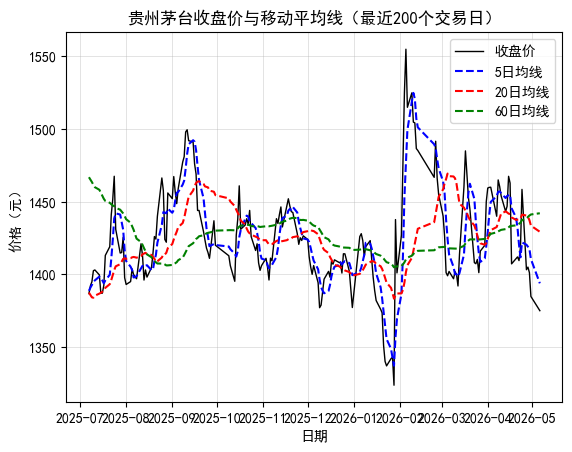

'title：设置图表标题。\nxlabel / ylabel：x 轴 / y 轴的标签。\nlegend：显示图例（自动使用 label 参数的内容）。\ngrid(True)：显示背景网格线，方便读数值。\nshow：渲染并显示出图表。\n'

In [9]:
# 可视化 （只画最近200个交易日，避免图像过密）
import matplotlib.pyplot as plt # 导入 Matplotlib 的绘图模块。
# plt.figure(figsize=(14, 6))  创建一个新的空白画布，设置宽度14英寸，高度6英寸
plt.rcParams['font.sans-serif'] = ['SimHei']   # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题
plt.plot(df.index[-200:],df['收盘'][-200:],label='收盘价',color='black',linewidth=1)
plt.plot(df.index[-200:],df['MA5'][-200:],label='5日均线',color='blue',linestyle='--')
plt.plot(df.index[-200:],df['MA20'][-200:],label='20日均线',color='red',linestyle='--')
plt.plot(df.index[-200:],df['MA60'][-200:],label='60日均线',color='green',linestyle='--')

plt.title('贵州茅台收盘价与移动平均线（最近200个交易日）')
plt.xlabel('日期')
plt.ylabel('价格（元）')
plt.legend()
plt.grid(True)
plt.show()
'''title：设置图表标题。
xlabel / ylabel：x 轴 / y 轴的标签。
legend：显示图例（自动使用 label 参数的内容）。
grid(True)：显示背景网格线，方便读数值。
show：渲染并显示出图表。
'''


## 均线的实际意义
# MA5：短线趋势，对价格变化敏感，但假信号多。
# MA20：中期趋势，常用来确认一个波段的方向。
# MA60：长期趋势，一般被认为是“生命线”，价格在 MA60 上方做多，下方做空，是一个简单的趋势跟踪策略。

In [10]:
# 基于移动平均线的简单交易信号
# 生成信号：1 表示买入（金叉），-1 表示卖出（死叉），0 表示无操作
df['signal']=0
df.loc[df['MA5']>df['MA20'],'signal']=1     # 当前市价下，短期均线高于长期均线 → 持有多头信号
df.loc[df['MA5']<df['MA20'],'signal']=-1    # 短期均线低于长期均线 → 持有空头信号
# 捕捉金叉和死叉瞬间（今日信号与昨日不同）
df['position']=df['signal'].diff()    # diff() 计算相邻变化：2 表示从 -1 变到 1（金叉），-2 表示从 1 变到 -1（死叉）
#金叉：前一天 MA5 ≤ MA20，今天 MA5 > MA20 → 买入
#死叉：前一天 MA5 ≥ MA20，今天 MA5 < MA20 → 卖出

In [11]:
# 更精准的金叉/死叉信号
# 当短期均线从下方上穿长期均线时，为金叉（买入信号）
df['golden']=(df['MA5']>df['MA20'])&(df['MA5'].shift(1)<=df['MA20'].shift(1))
# 当短期均线从上方下穿长期均线时，为死叉（卖出信号）
df['death']=(df['MA5']<df['MA20'])&(df['MA5'].shift(1)>=df['MA20'].shift(1))

# 移动平均线（MA）是一种趋势跟踪指标。
MA5 是最近5天收盘价的平均，反应短期价格变动。
MA20 是最近20天收盘价的平均，反应中期趋势。
当 MA5 > MA20 时，意味着最近5天的平均价格已经超过了最近20天的平均价格，表明短期的上涨势头强于中期，通常被看作是上升趋势可能开始的信号（俗称“金叉”）。此时买入，是希望顺势而为，在趋势启动时入场。
反之，当 MA5 < MA20 时，短期弱于中期，认为是下跌趋势（死叉），卖出或空仓。
注意： 这只是一个简化的技术指标，不是百分之百准确。实际交易中，金叉可能出现在震荡市或假突破中，所以需要结合其他条件（如成交量、市场环境）来过滤信号。不过，对于初学量化策略，它是一个很好的入门信号。

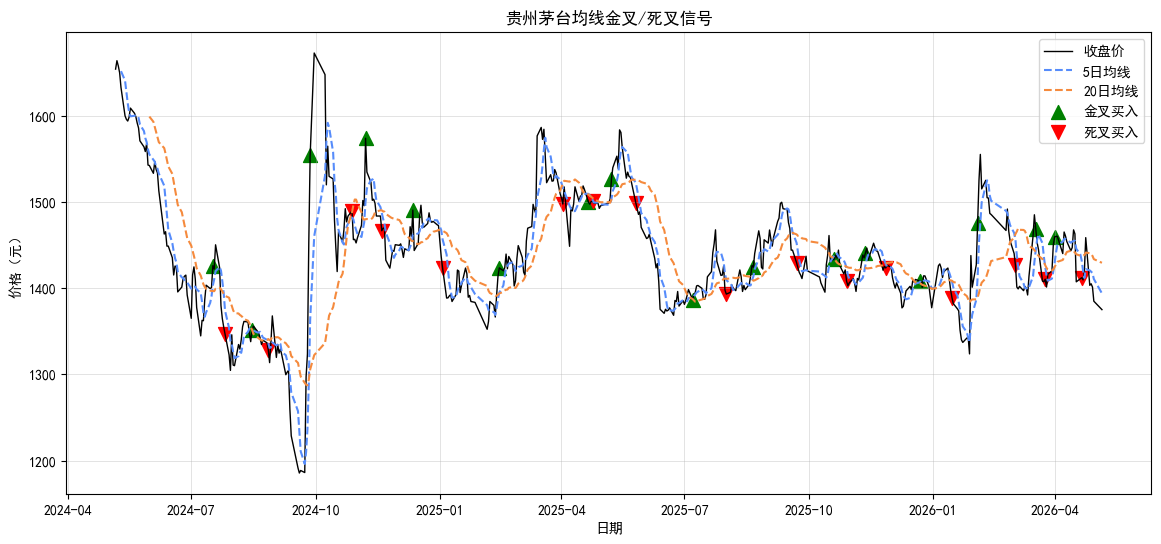

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(df.index,df['收盘'],label='收盘价',color='black',linewidth=1)
plt.plot(df.index,df['MA5'],label='5日均线',linestyle='--')
plt.plot(df.index,df['MA20'],label='20日均线',linestyle='--')

# 金叉
plt.scatter(df.index[df['golden']],df['收盘'][df['golden']],
            marker='^',color='green',s=100,label='金叉买入')
# 死叉
plt.scatter(df.index[df['death']],df['收盘'][df['death']],
            marker='v',color='red',s=100,label='死叉买入')

plt.title('贵州茅台均线金叉/死叉信号')
plt.xlabel('日期')
plt.ylabel('价格（元）')
plt.legend()
plt.grid()
plt.show()

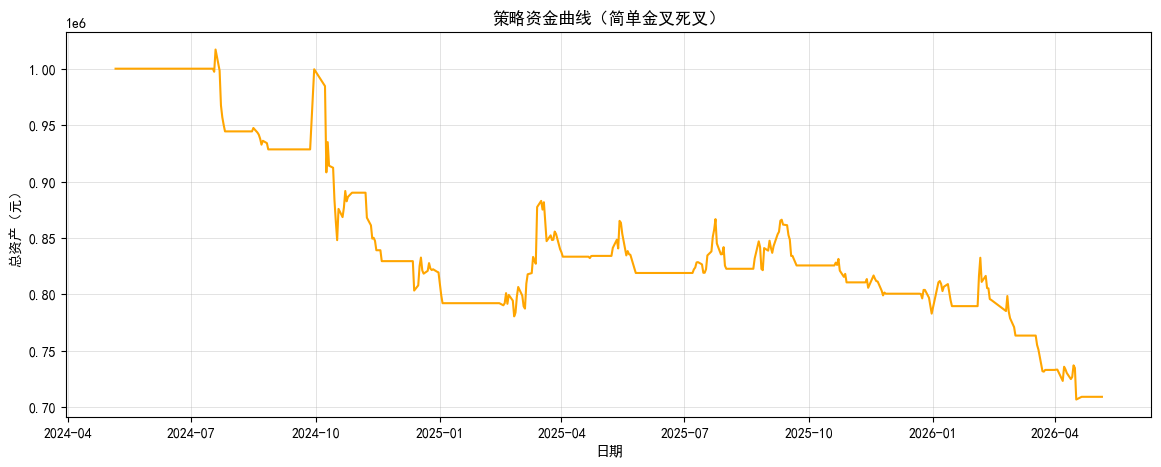

最终总资产：709293.19元
总收益：-29.07%


In [13]:
# 模拟交易（简单回测思路）
# 假设初始资金100万，每次信号出现就全仓买入或清仓（简单处理，不考虑手续费）
# 初始化资金和持仓
cash=1000000
hold=0        # 持股数量
equity=[]     # 每日总资产
for i in range(len(df)):
    if df['golden'].iloc[i] and hold == 0:     # 如果今天是金叉且手里没股票 -> 全仓买入
        hold=cash/df['收盘'].iloc[i]
        cash=0
    elif df['death'].iloc[i] and hold>0:       # 如果今天是死叉且手里有股票 -> 全部卖出
        cash=hold*df['收盘'].iloc[i]
        hold=0
    total=cash+hold*df['收盘'].iloc[i]          # 不管有没有交易，每天记录总资产 = 现金 + 股票市值
    equity.append(total)
df['equity']=equity

plt.figure(figsize=(14,5))
plt.plot(df.index,df['equity'],color='orange')
plt.title('策略资金曲线（简单金叉死叉）')
plt.xlabel('日期')
plt.ylabel('总资产（元）')
plt.grid()
plt.show()

print(f"最终总资产：{df['equity'].iloc[-1]:.2f}元")
print(f"总收益：{(df['equity'].iloc[-1]/1000000-1)*100:.2f}%")

In [14]:
print(df.columns)

Index(['股票代码', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率',
       'ret', 'log_ret', 'MA5', 'MA20', 'MA60', 'signal', 'position', 'golden',
       'death', 'equity'],
      dtype='str')


In [17]:
equity=df['equity'].dropna()  # 取出 equity 列，去掉缺失值
daily_returns=equity.pct_change().dropna()  # 计算每日收益率（percentage change）
daily_returns.head()   #检查是否去掉缺失值

日期
2024-05-07    0.0
2024-05-08    0.0
2024-05-09    0.0
2024-05-10    0.0
2024-05-13    0.0
Name: equity, dtype: float64